In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
df = pd.read_csv('Churn_Modelling.csv')

In [4]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df.shape

(10000, 14)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [9]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [10]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [11]:
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)

In [12]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [13]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True, dtype=int)

In [14]:
from sklearn.model_selection import train_test_split
X = df.drop('Exited', axis=1)
y = df['Exited']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
X_train_scaled

array([[ 0.35649971, -0.6557859 ,  0.34567966, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [-0.20389777,  0.29493847, -0.3483691 , ...,  1.72572313,
        -0.57638802,  0.91324755],
       [-0.96147213, -1.41636539, -0.69539349, ..., -0.57946723,
         1.73494238,  0.91324755],
       ...,
       [ 0.86500853, -0.08535128, -1.38944225, ..., -0.57946723,
        -0.57638802, -1.09499335],
       [ 0.15932282,  0.3900109 ,  1.03972843, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [ 0.47065475,  1.15059039, -1.38944225, ...,  1.72572313,
        -0.57638802,  0.91324755]], shape=(8000, 11))

In [18]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [19]:
model = Sequential()

model.add(Dense(8, activation='relu', input_dim = 11))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

d:\whole ML\mlvenv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 177 (708.00 B)

 Trainable params: 177 (708.00 B)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [22]:
history = model.fit(X_train_scaled, y_train, epochs=40, validation_split=0.2)

Epoch 1/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7011 - loss: 0.6014 - val_accuracy: 0.7987 - val_loss: 0.5037
Epoch 2/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 743us/step - accuracy: 0.7934 - loss: 0.4881 - val_accuracy: 0.7987 - val_loss: 0.4586
Epoch 3/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 722us/step - accuracy: 0.7937 - loss: 0.4594 - val_accuracy: 0.7994 - val_loss: 0.4362
Epoch 4/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 725us/step - accuracy: 0.8023 - loss: 0.4439 - val_accuracy: 0.8119 - val_loss: 0.4234
Epoch 5/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 793us/step - accuracy: 0.8102 - loss: 0.4338 - val_accuracy: 0.8244 - val_loss: 0.4158
Epoch 6/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 748us/step - accuracy: 0.8153 - loss: 0.4259 - val_accuracy: 0.8300 - val_loss: 0.4097
Epoch 7/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 723us/step - accuracy: 0.8227 - loss: 0.4183 - val_accuracy: 0.8394 - val_loss: 0.4030
Epoch 8/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 708us/step - accuracy: 0.8311 - loss: 0.4071 - va

In [23]:
model.layers[0].get_weights()

[array([[-3.67170200e-02, -3.89423743e-02, -9.28387940e-02,
          1.59926303e-02,  1.87454239e-01, -7.57662430e-02,
         -1.25353843e-01, -1.00412615e-01],
        [-7.13104129e-01,  2.03785285e-01,  2.72826068e-02,
         -7.95755029e-01, -7.78355449e-02,  6.59343839e-01,
         -4.86590862e-01,  2.11826220e-01],
        [ 4.36152183e-02,  9.06497240e-04, -4.14120667e-02,
         -1.08099826e-01, -2.79666960e-01,  5.73283955e-02,
          2.20577762e-01, -5.40002212e-02],
        [ 3.41611743e-01, -1.97716966e-01,  1.03729248e+00,
          7.72897452e-02, -3.17419320e-01,  2.76214242e-01,
         -2.63393730e-01,  1.30773857e-01],
        [-1.78008467e-01, -1.30090117e+00,  8.26627791e-01,
          5.05679399e-02,  5.82645059e-01,  1.21338584e-01,
          4.58444655e-02,  9.98361528e-01],
        [ 3.30694616e-02, -6.14237972e-03,  3.16140801e-02,
         -6.20815754e-02, -2.87286818e-01,  1.46734893e-01,
          9.02496055e-02, -1.74857602e-02],
        [-3.8257

In [24]:
model.layers[1].get_weights()


[array([[ 0.07157631,  0.37625062, -0.6160033 ,  0.22315659,  0.22734335,
          0.6563025 , -0.56397617, -0.01109594],
        [ 0.04365994,  1.0711987 ,  0.53045195,  0.03037696, -0.28815627,
         -0.41970178, -0.567753  , -0.22932188],
        [-0.17785607,  0.39752182,  0.34588516, -1.2365294 , -0.76564795,
          0.16037188, -0.4543724 ,  0.08463175],
        [ 1.0666723 ,  0.21538325, -0.43388733,  0.09204777, -0.05936098,
          0.3530403 , -0.49058533,  0.48097196],
        [ 0.30598488,  0.13678256,  0.42623472,  0.9322736 ,  0.60357845,
          0.00426864, -0.40833837,  0.64622784],
        [ 0.548824  , -0.6659179 , -0.32070646,  0.40854543,  0.684657  ,
         -0.62324697, -0.23060481,  0.8248178 ],
        [ 0.21513486,  0.46786433, -0.04943059,  0.01220379,  0.6019644 ,
          0.52916414, -0.52815455, -0.04481642],
        [-0.06824619,  1.2015646 ,  0.4014899 , -0.2810217 , -0.39193377,
         -0.3666292 ,  0.288709  , -0.6406267 ]], dtype=float32),

In [25]:
y_log = model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 646us/step


In [26]:
y_pred = np.where(y_log > 0.5, 1, 0)

In [27]:
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, y_pred)
acc

0.8645

In [28]:
import matplotlib.pyplot as plt

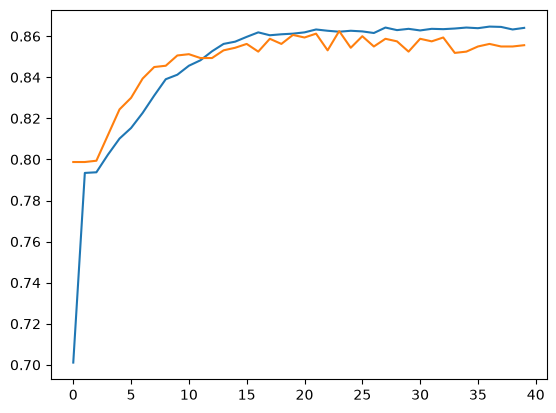

In [29]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'], )

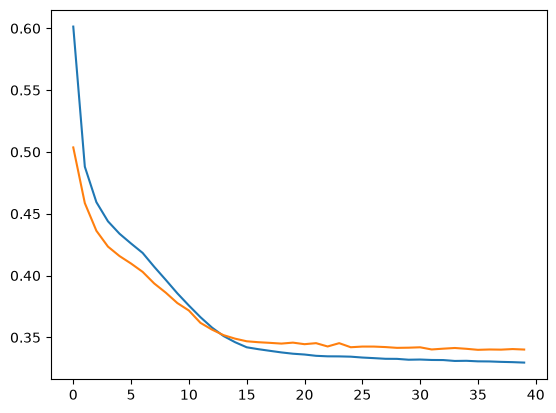

In [30]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')